# Introducción a las Galaxias de Disco y el Modelo de Toomre

Las galaxias de disco son sistemas complejos formados por miles de millones de estrellas que orbitan alrededor de un centro masivo. Intentar modelar computacionalmente la física real de una galaxia completa, con todas las fuerzas gravitacionales que ejercen las estrellas entre sí (un problema de N-cuerpos completo), tiene un costo computacional prohibitivo.

Para solucionar este inconveniente computacional y poder estudiar la dinámica y las colisiones galácticas, se utiliza el **Modelo de Toomre**. Este modelo simplifica el sistema drásticamente mediante dos supuestos clave:

1. **Núcleos puntuales:** Cada galaxia es dominada por un núcleo masivo central que es tratado como una partícula puntual con masa mayor al resto, y obedece las leyes de la gravedad de Newton (estos núcleos sí se atraen entre sí).
2. **Estrellas como "partículas de prueba":** Las estrellas que componen el disco galáctico se simulan como partículas de **masa cero**. Ellas orbitan reaccionando al campo gravitacional de los núcleos masivos, pero *no interactúan gravitacionalmente entre sí ni afectan a los núcleos*.

A pesar de que el Modelo de Toomre descarta factores como la fricción, presiones de gas o los halos de materia oscura, es una herramienta sumamente poderosa y eficiente para la intuición astronómica, permitiendo estudiar cinemática orbital a muy bajo costo de cómputo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from numba import jit

from typing import Tuple, List, Dict, Any


## 1. Clase Base: Sistema de Partículas y Dinámica

En esta sección implementamos la estructura fundamental de la simulación. El **Modelo de Toomre (1972)** es una simulación de $N$-cuerpos restringida: asume que las estrellas son partículas de **masa cero** ("test particles") que responden al potencial gravitacional de núcleos masivos, pero **no interactúan gravitacionalmente entre sí**. Esto reduce drásticamente el costo computacional de $\mathcal{O}(N^2)$ a $\mathcal{O}(N \times N_{nucl})$, permitiendo simular el disco con miles de partículas fluidamente.


### Optimización con Numba
Para mantener un alto rendimiento en Python puro con bucles, extraemos el cálculo de fuerzas a una función estática `@jit(nopython=True)`, lo que compila la parte pesada de la simetría a lenguaje C.

In [ ]:
class Sistema:

    def __init__(self, particles: List[Dict[str, Any]]):

        '''
        Clase que representa un sistema general de partículas, que pueden ser núcleos masivos o estrellas de masa cero.
        params:
        - particles: lista de diccionarios con la información de las partículas (núcleos y estrellas)
            - Cada partícula es un diccionario con las siguientes claves:
                - 'mass': masa de la partícula (0 para estrellas)
                - 'position': posición inicial (array de 3 elementos)
                - 'velocity': velocidad inicial (array de 3 elementos)
        '''
        if particles is None or not isinstance(particles, list):
            print("No se proporcionó una lista válida de partículas.\n\
                  Se inicializa el sistema sin partículas.")
            self.particles = []
        else:
            self.particles = particles

        ## Masa del sistema, es la suma de las masas de todas las partículas
        self.mass = sum(particle['mass'] for particle in particles)
        # Número de partículas, posiciones y velocidades iniciales
        self.num_particles = len(particles)
        # ïndices de partículas con masa
        self.mass_indices = np.where(np.array([particle['mass'] for particle in particles]) > 0)[0]

        # Almacenamos las posiciones y velocidades iniciales en arrays para facilitar los cálculos posteriores
        self.masses = np.array([particle['mass'] for particle in particles])
        self.positions = np.array([particle['position'] for particle in particles])
        self.velocities = np.array([particle['velocity'] for particle in particles])


        ## tiempo de relajación del sistema
        v_prom = np.mean(np.linalg.norm(self.velocities, axis=1))
        n = self.num_particles
        self.t_relax = (n / (8 * np.log(n))) * (self.mass / v_prom**3) if v_prom > 0 else np.inf


    # Un método estático (@staticmethod) no recibe la instancia de la clase ('self')
    # como argumento y funciona realmente como una función "independiente" agrupada aquí.
    # Lo usamos porque Numba (@jit / @njit) solo compila tipos matemáticos de NumPy y
    # primitivos nativos; si a Numba le pasáramos 'self' o atributos con diccionarios
    # y listas (como self.particles), fallaría al intentar compilarlos.
    @staticmethod
    @jit(nopython=True)  # @njit es simplemente un alias corto para @jit(nopython=True)
    def get_accelerations(positions, masses, massive_indices, num_particles):
        '''
        Calcula simultáneamente las aceleraciones de todas las partículas bajo el
        influjo de los núcleos masivos, optimizado a nivel de C con Numba.

        $$a = \sum_{k \in massive_indices} G * m_k * (r_i - r_k) / |r_i - r_k|^3$$

        parametros:
        - positions: array de posiciones de las partículas (num_particles x 3)
        - masses: array de masas de las partículas (num_particles)
        - massive_indices: array de índices de las partículas que son núcleos masivos
        - num_particles: número total de partículas en el sistema

        '''
        a = np.zeros((num_particles, 3), dtype=np.float64)
        for i in range(num_particles):
            for k in massive_indices:
                if i != k:
                    dx = positions[i, 0] - positions[k, 0]
                    dy = positions[i, 1] - positions[k, 1]
                    dz = positions[i, 2] - positions[k, 2]
                    r_mag = np.sqrt(dx**2 + dy**2 + dz**2)
                    if r_mag > 0:
                        factor = masses[k] / (r_mag**3)
                        a[i, 0] -= factor * dx
                        a[i, 1] -= factor * dy
                        a[i, 2] -= factor * dz
        return a

    def integrate(self, dt: float, T: float,
                  actualizar: bool = False
                  )-> np.ndarray:
        '''Integramos el problema usando leapfrog

        Necesitamos las posiciones y velocidades iniciales de las partículas, así como sus masas.
        Luego, en cada paso de tiempo, calculamos las fuerzas gravitacionales entre los núcleos masivos y las estrellas
        (teniendo en cuenta que las estrellas no interactúan entre sí), actualizamos las velocidades de las estrellas y
        luego sus posiciones.
        '''

        num_steps = int(T / dt)

        trajectory = np.zeros((num_steps, self.num_particles, 3))

        # 1. astype(np.float64): Numba es de tipado estricto. Si le pasamos enteros mezclados con flotantes,
        # la compilación puede fallar. Aseguramos que todo sea float64 para máxima compatibilidad.
        # 2. copy=True: En NumPy, 'a = b' solo crea una referencia. Si más abajo hacemos 'a += 1', 'b' también se modifica.
        # Creamos copias explícitas aislando la memoria, así las variables de la clase (self.xxx) no se modifican
        # accidentalmente durante la simulación (útil si actualizar=False).
        positions = self.positions.astype(np.float64, copy=True)
        velocities = self.velocities.astype(np.float64, copy=True)
        masses = self.masses.astype(np.float64)

        trajectory[0] = positions

        massive_indices = self.mass_indices

        # Calculamos aceleraciones iniciales llamando a la función JIT compilada
        a_i = self.get_accelerations(positions, masses, massive_indices, self.num_particles)
        velocities += 0.5 * a_i * dt  # Medio paso de leapfrog iterando rápido

        # Iteramos sobre cada paso usando la Numba JIT para las aceleraciones
        for step in range(1, num_steps):
            positions += velocities * dt
            trajectory[step] = positions

            # Nueva aceleración
            a_i = self.get_accelerations(positions, masses, massive_indices, self.num_particles)
            velocities += a_i * dt

        if actualizar:
            self.positions = positions
            self.velocities = velocities
            # Sincronizamos las partículas para no dejar inconsistente los diccionarios
            for i in range(self.num_particles):
                self.particles[i]['position'] = positions[i]
                self.particles[i]['velocity'] = velocities[i]

        return trajectory

    # Cuadraturas del sistema

    ## Momento angular total del sistema
    def angular_momentum(self):
        '''Calcula el momento angular total del sistema, que es la suma del momento angular de cada partícula.

        El momento angular de una partícula se calcula como L = r x (m * v), donde r es la posición de la partícula,
        m es su masa y v es su velocidad. Para las estrellas, m=0, por lo que no contribuyen al momento angular.
        '''
        L_total = np.zeros(3)
        for particle in self.particles:
            if particle['mass'] > 0:  # Solo consideramos el momento angular de los núcleos masivos
                r = particle['position']
                v = particle['velocity']
                m = particle['mass']
                L_total += np.cross(r, m * v)
        return L_total


    ## Energía total del sistema
    def total_energy(self):
        '''Calcula la energía total del sistema, que es la suma de la energía cinética y la energía potencial gravitatoria.

        La energía cinética de una partícula se calcula como K = 0.5 * m * v^2, donde m es la masa de la partícula
        y v es su velocidad. Para las estrellas, m=0, por lo que no contribuyen a la energía cinética.

        La energía potencial gravitatoria entre dos partículas se calcula como U = -G * m1 * m2 / r, donde G es la
        constante gravitacional (que asumimos G=1), m1 y m2 son las masas de las partículas y r es la distancia entre ellas.
        Solo consideramos la energía potencial entre los núcleos masivos, ya que las estrellas no interactúan entre sí.
        '''
        K_total = 0.0
        U_total = 0.0

        # Calcular energía cinética
        for particle in self.mass_indices:
            m = particle['mass']
            v = particle['velocity']
            K_total += 0.5 * m * np.dot(v, v)
        # Calcular energía potencial entre núcleos masivos
        massive_particles = [p for p in self.particles if p['mass'] > 0]
        for i in range(len(massive_particles)):
            for j in range(i + 1, len(massive_particles)):
                m1 = massive_particles[i]['mass']
                m2 = massive_particles[j]['mass']
                r_vec = massive_particles[i]['position'] - massive_particles[j]['position']
                r_mag = np.linalg.norm(r_vec)
                if r_mag > 0:
                    U_total -= (m1 * m2) / r_mag  # G=1

        return K_total + U_total

    ## plot posiciones de las partículas en 2D
    def plot_positions(self):
        '''Genera un gráfico 2D (plano XY) de las posiciones de las partículas en el sistema.
        Los núcleos masivos se representan con un color diferente a las estrellas de masa cero.
        '''
        plt.figure(figsize=(7, 7))

        # Obtener las masas para filtrar índices
        masses = self.masses
        massive_idx = self.mass_indices
        stars_idx = np.where(masses == 0)[0]

        # Graficar usando self.positions directamente
        plt.scatter(self.positions[stars_idx, 0], self.positions[stars_idx, 1],
                    s=3, c='blue', label='Estrellas de masa cero')
        plt.scatter(self.positions[massive_idx, 0], self.positions[massive_idx, 1],
                    s=50, c='red', label='Núcleo masivo')

        plt.title('Posiciones de las partículas en el sistema (2D)')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.axis('equal')
        plt.legend()
        plt.show()


    def animate_trajectories(self, trayectorias = None, actualizar: bool = False,
                             dt = None, T = None, step_skip: int = 1,
                             limite_ejes: float = None):
        '''
        Genera una animación de las trayectorias de las partículas a lo largo del tiempo. En formato HTML5 para Jupyter Notebook.

        params:
        - trayectorias: array de forma (num_steps, num_particles, 3) con las posiciones de las partículas en cada paso de tiempo.
                    Si es None, se calcula la trayectoria usando el método integrate con los parámetros por defecto.
        - step_skip: int. Toma un fotograma cada cantidad de pasos especificada para reducir el peso de la animación.
        - limite_ejes: float. Establece el límite de los ejes para la animación.
        '''

        if trayectorias is None:
            try:
                trayectorias = self.integrate(dt=dt, T=T, actualizar=actualizar)
            except Exception as e:
                print(f"Error al calcular trayectorias: {e}")
                return

        # Filtramos la trayectoria según la cantidad de fotogramas a saltar
        if step_skip > 1:
            trayectorias = trayectorias[::step_skip]

        from matplotlib.animation import FuncAnimation
        from IPython.display import HTML
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.set_title('Animación de trayectorias de las partículas')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        if limite_ejes is None:
            # Si no se especifica es 1.5 veces el máximo radio de las posiciones iniciales para asegurar que se vean todas las partículas
            max_radius = np.max(np.linalg.norm(self.positions[:, :2], axis=1))
            limite_ejes = max_radius * 1.5
        ax.set_ylim(-limite_ejes, limite_ejes)
        ax.set_xlim(-limite_ejes, limite_ejes)
        ax.axis('equal')
        # Obtener las masas para filtrar índices
        masses = self.masses
        massive_idx = self.mass_indices
        stars_idx = np.where(masses == 0)[0]
        # Inicializar los puntos de las partículas
        points_stars, = ax.plot([], [], 'bo', markersize=3, label='Estrellas de masa cero')
        points_massive, = ax.plot([], [], 'ro', markersize=8, label='Núcleo masivo')
        ax.legend()
        def init():
            points_stars.set_data([], [])
            points_massive.set_data([], [])
            return points_stars, points_massive
        def update(frame):
            points_stars.set_data(trayectorias[frame, stars_idx, 0], trayectorias[frame, stars_idx, 1])
            points_massive.set_data(trayectorias[frame, massive_idx, 0], trayectorias[frame, massive_idx, 1])
            return points_stars, points_massive
        anim = FuncAnimation(fig, update, frames=trayectorias.shape[0], init_func=init, blit=True)
        plt.close(fig)  # Evitar mostrar la figura
        return HTML(anim.to_jshtml())

<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
C:\Users\User\AppData\Local\Temp\ipykernel_44964\2666790335.py:48: SyntaxWarning: invalid escape sequence '\s'
  '''


Probemos nuestro generador de sistemas

In [ ]:
particulas = [
    {"mass": 1e3, "position": np.array([0.0, 0.0, 0.0]), "velocity": np.array([0.0, 0.0, 0.0])}
]

## añadimos al rededor del núcleo de forma aleatoria 1000 estrellas de masa cero

for _ in range(1000):
    r = np.random.uniform(0.1, 10.0)  # Distancia aleatoria entre 0.1 y 10 unidades
    theta = np.random.uniform(0, 2 * np.pi)  # Ángulo azimutal aleatorio
    phi = np.random.uniform(0, np.pi)  # Ángulo polar aleatorio

    # Convertimos las coordenadas esféricas a cartesianas
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)

    position = np.array([x, y, z])
    velocity = np.array([0.0, 0.0, 0.0])  # Velocidad inicial de las estrellas

    particulas.append({"mass": 0.0, "position": position, "velocity": velocity})



In [ ]:
intento = Sistema(particulas)

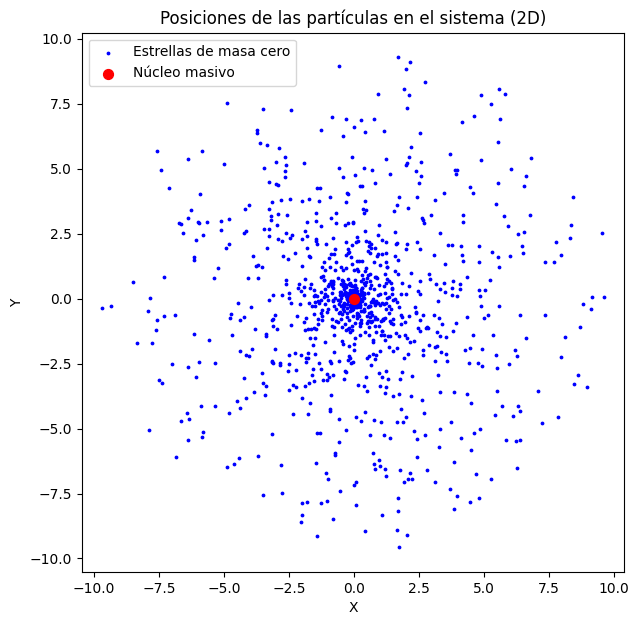

In [ ]:
intento.positions

intento.plot_positions()

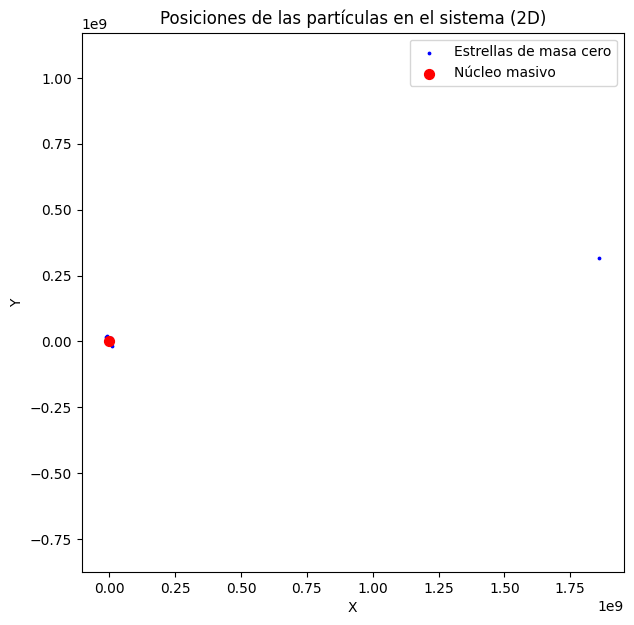

In [ ]:
trayectorias = intento.integrate(dt=0.01, T=10.0, actualizar=True)

intento.plot_positions()

## 2. Construcción del Disco Galáctico (Condiciones Iniciales)

La clase `Galaxia` especializa el `Sistema` para recrear un disco prístino:
- Se sitúa un **núcleo masivo** de masa $M$ en el origen que domina el pozo de potencial.
- Las **partículas estelares** (masa cero) se distribuyen de manera uniforme (o aleatoria) desde un `radio_min` a un `radio_max`. El radio mínimo evita singularidades donde la aceleración tiende a infinito al solaparse con la posición del núcleo masivo.
- Se impone un **Equilibrio Centrífugo** ("rotación circular perfecta"). La velocidad de una estrella en la órbita $r$ se asigna equilibrando la gravedad y la fuerza centrípeta: $v = \sqrt{G M / r}$, eligiendo el vector de velocidad perpendicular al radio vector $\hat{r}$.

### Concepto de Programación: Herencia y el uso de `super()`

En Python, apoyarse de la **Programación Orientada a Objetos** permite ahorrar mucho código y esfuerzo matemático. Aquí vemos esto en acción cuando declaramos `class Galaxia(Sistema)`:

1. **Herencia (`class Galaxia(Sistema)`):** Esto le indica a Python que la clase `Galaxia` es una "hija" de la clase base `Sistema`. Como resultado, `Galaxia` hereda automáticamente todos los métodos de su padre: `integrate()`, `plot_positions()`, `total_energy()`, etc. No tenemos que reescribir la física del Leapfrog ni las métricas de N-cuerpos.
2. **Método `super()`:** Al construir una `Galaxia` (en el `__init__`), necesitamos generar un disco con características especiales (partículas en órbitas circulares). Una vez que hemos calculado y agrupado todas estas posiciones y velocidades iniciales en la lista `particles`, utilizamos `super().__init__(particles)`. Esto básicamente significa: *"Oye clase padre (`Sistema`), aquí te paso las partículas generadas con mi lógica particular; encárgate tú de convertirlas en arrays de numpy, identificar cuáles son núcleos y cuáles estrellas, contar las partículas y configurar el sistema tal y como ya sabes hacerlo."*

In [ ]:
class Galaxia(Sistema):
    '''Clase que representa una galaxia de disco según el modelo de Toomre.
    Hereda de la clase Sistema, pero con condiciones específicas para representar una galaxia de disco.
    '''
    def __init__(self, num_estrellas: int,
                 masa_nucleo: float,
                 radio_max: float,
                 radio_min: float = 0.5,
                 sentido_rotacion: int = 1):
        '''
        Inicializa una galaxia de disco con un núcleo masivo central y un conjunto de estrellas distribuidas en un disco alrededor del núcleo.

        params:
        - num_estrellas: número de estrellas (partículas de masa cero) en el disco
        - masa_nucleo: masa del núcleo masivo central
        - radio_max: radio máximo del disco de estrellas
        - radio_min: radio mínimo del disco de estrellas (default 0.5)
        - sentido_rotacion: 1 para anti-horario, -1 para horario.
        '''
        particles = []
        # Núcleo masivo central
        particles.append({"mass": masa_nucleo, "position": np.array([0.0, 0.0, 0.0]), "velocity": np.array([0.0, 0.0, 0.0])})

        # Estrellas distribuidas en un disco alrededor del núcleo
        for _ in range(num_estrellas):
            r = np.random.uniform(radio_min, radio_max)  # Distancia aleatoria entre radio_min y radio_max
            theta = np.random.uniform(0, 2 * np.pi)  # Ángulo aleatorio en el plano XY

            # Coordenadas cartesianas en el plano XY (disco)
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            z = 0.0  # Las estrellas están en el plano del disco

            position = np.array([x, y, z])

            # Velocidad circular inicial para las estrellas: v = sqrt(M / r) asumiendo G=1
            v_mag = np.sqrt(masa_nucleo / r)

            # Velocidad perpendicular a la posición (-sin(theta), cos(theta)) multiplicada por el sentido de rotación
            vx = -sentido_rotacion * v_mag * np.sin(theta)
            vy = sentido_rotacion * v_mag * np.cos(theta)
            vz = 0.0

            velocity = np.array([vx, vy, vz])

            particles.append({"mass": 0.0, "position": position, "velocity": velocity})

        super().__init__(particles)

In [ ]:
galaxia1 = Galaxia(num_estrellas=1000, masa_nucleo=1e3,
                   radio_max=10.0, radio_min = 3)

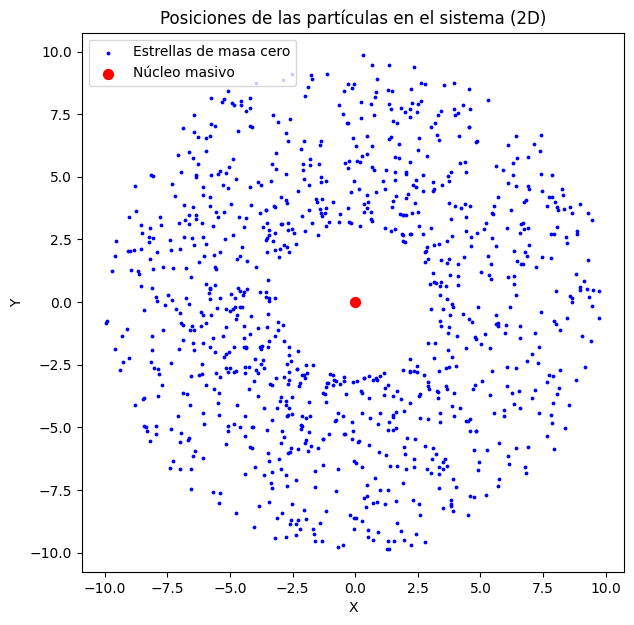

In [ ]:
galaxia1.plot_positions()

In [ ]:
galaxia1.animate_trajectories(dt=0.01, T=10.0, step_skip= 10)

## 3. Ensamblaje de Colisiones (Sistemas Combinados)

Para estudiar **interacciones de marea** (fuerzas de marea, formación de colas y puentes), la clase `Merged_sistem` nos permite colocar varias copias de objetos `Galaxia` en el mismo espacio.
El manejo de los offset de posición (`position_offset`) y velocidad (`velocity_offset`) permite elegir órbitas de colisión (parabólicas, hiperbólicas, etc). Por ejemplo:
- Si asignamos velocidad orbital transversal a los sistemas, podemos generar una colisión frontal, de impacto lateral o "grazing".
- Aquí registramos un **`system_id`** para que, durante las gráficas de evolución temporal, se puedan identificar las estrellas "robadas" por interacción de marea o la estructura propia (como la disrupción del disco) de cada galaxia independiente.

In [ ]:
class Merged_sistem(Sistema):
    def __init__(self, sistemas: List[Sistema],
                 position_offset: List[np.ndarray] = None,
                 velocity_offset: List[np.ndarray] = None):

        '''
        Crea un sistema combinado a partir de una lista de sistemas individuales,
        aplicando desplazamientos de posición y velocidad opcionales a cada sistema.
        Si no se asiganan posiciones, los sistemas se distribuyen automáticamente en los
        vértices de un polígono regular (o enfrentados si son 2), con separación radial
        basada en el sistema más grande.
        '''

        self.num_sistemas = len(sistemas)
        if position_offset is None:
            # Buscamos el radio máximo global entre todos los sistemas (para usarlo como referencia)
            r_max_global = 0.0
            for sistema in sistemas:
                # El máximo de la magnitud de la posición nos dice qué tan "ancha" es la galaxia
                r_max_actual = np.max(np.linalg.norm(sistema.positions, axis=1))
                if r_max_actual > r_max_global:
                    r_max_global = r_max_actual

            # El radio del polígono en el que vamos a ubicar las galaxias es 2 veces el r_max
            R_poligono = 2.0 * r_max_global

            position_offset = []
            for i in range(self.num_sistemas):
                if self.num_sistemas == 1:
                    position_offset.append(np.zeros(3))
                elif self.num_sistemas == 2:
                    # Para 2 sistemas, los colocamos directamente opuestos sobre el eje X
                    signo = 1 if i == 0 else -1
                    position_offset.append(np.array([signo * R_poligono, 0.0, 0.0]))
                else:
                    # Formamos un polígono regular en el plano XY
                    angulo = i * (2 * np.pi / self.num_sistemas)
                    position_offset.append(np.array([R_poligono * np.cos(angulo), R_poligono * np.sin(angulo), 0.0]))

        if velocity_offset is None:
            velocity_offset = [np.zeros(3) for _ in range(self.num_sistemas)]

        particles = []
        self.indices_sistemas = []
        current_idx = 0

        for i, sistema in enumerate(sistemas):
            for particle in sistema.particles:
                new_particle = {
                    "mass": particle['mass'],
                    "position": particle['position'] + position_offset[i],
                    "velocity": particle['velocity'] + velocity_offset[i],
                    "system_id": i + 1 # Etiqueta extra para identificar el sistema del que proviene
                }
                particles.append(new_particle)

            start_idx = current_idx
            current_idx += len(sistema.particles)
            end_idx = current_idx

            # guardemos los rangos de índices de cada sistema para poder analizarlos por separado
            self.indices_sistemas.append((start_idx, end_idx))

        super().__init__(particles)

        # Guardamos un array de IDs para facilitar filtros con NumPy
        self.system_ids = np.zeros(self.num_particles, dtype=int)
        for i, (start, end) in enumerate(self.indices_sistemas):
            self.system_ids[start:end] = i + 1

    def plot_positions(self):
        '''Genera un gráfico 2D diferenciando por color cada subsistema.'''
        plt.figure(figsize=(7, 7))

        # Paletas de colores predefinidas para diferenciar sistemas (soporta hasta varias galaxias)
        colores_estrellas = ['blue', 'cyan', 'green', 'purple', 'pink']
        colores_nucleos = ['red', 'orange', 'darkred', 'brown', 'magenta']

        for i, (start, end) in enumerate(self.indices_sistemas):
            # Posiciones y masas exclusivas de este sistema
            sys_masses = self.masses[start:end]
            sys_positions = self.positions[start:end]

            # Filtros de masa
            stars_mask = sys_masses == 0
            massive_mask = sys_masses > 0

            # Selección de color
            c_stars = colores_estrellas[i % len(colores_estrellas)]
            c_mass = colores_nucleos[i % len(colores_nucleos)]

            plt.scatter(sys_positions[stars_mask, 0], sys_positions[stars_mask, 1],
                        s=3, c=c_stars, label=f'Estrellas Sist. {i+1}', alpha=0.6)
            plt.scatter(sys_positions[massive_mask, 0], sys_positions[massive_mask, 1],
                        s=50, c=c_mass, label=f'Núcleo Sist. {i+1}')

        plt.title('Posiciones de las partículas (Sistemas Combinados)')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.axis('equal')
        plt.legend()
        plt.show()


    def animate_trajectories(self, trayectorias=None, actualizar: bool = False,
                         dt=None, T=None, step_skip: int = 1,
                         limite_ejes: float = None):
        '''
        Sobrescribe la animación para incluir los colores según subsistema en Merged_sistem.
        '''
        if trayectorias is None:
            try:
                trayectorias = self.integrate(dt=dt, T=T, actualizar=actualizar)
            except Exception as e:
                print(f"Error al calcular trayectorias: {e}")
                return

        if step_skip > 1:
            trayectorias = trayectorias[::step_skip]

        from matplotlib.animation import FuncAnimation
        fig, ax = plt.subplots(figsize=(7, 7))

        ax.set_facecolor('black')
        ax.set_title('Animación de trayectorias (Sistemas Combinados)')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

        if limite_ejes is None:
            max_radius = np.max(np.linalg.norm(self.positions[:, :2], axis=1))
            limite_ejes = max_radius * 1.5

        ax.set_ylim(-limite_ejes, limite_ejes)
        ax.set_xlim(-limite_ejes, limite_ejes)
        ax.axis('equal')

        colores_estrellas = ['blue', 'cyan', 'green', 'purple', 'pink']
        colores_nucleos = ['red', 'orange', 'darkred', 'brown', 'magenta']

        points_list = []
        indices_list = []

        for i, (start, end) in enumerate(self.indices_sistemas):
            stars_idx = np.where(self.masses[start:end] == 0)[0] + start
            massive_idx = np.where(self.masses[start:end] > 0)[0] + start

            c_stars = colores_estrellas[i % len(colores_estrellas)]
            c_mass = colores_nucleos[i % len(colores_nucleos)]

            p_stars, = ax.plot([], [], marker='o', linestyle='none', markersize=1,
                            color=c_stars, label=f'Estrellas Sist. {i+1}', alpha=0.3)
            p_massive, = ax.plot([], [], marker='o', linestyle='none', markersize=8,
                                color=c_mass, label=f'Núcleo Sist. {i+1}')

            points_list.extend([p_stars, p_massive])
            indices_list.extend([stars_idx, massive_idx])

        ax.legend(loc='upper right')

        def init():
            for p in points_list:
                p.set_data([], [])
            return points_list

        def update(frame):
            for p, idxs in zip(points_list, indices_list):
                if len(idxs) > 0:
                    p.set_data(trayectorias[frame, idxs, 0], trayectorias[frame, idxs, 1])
            return points_list

        anim = FuncAnimation(
            fig,
            update,
            frames=trayectorias.shape[0],
            init_func=init,
            blit=True
        )

        plt.close(fig)
        return anim

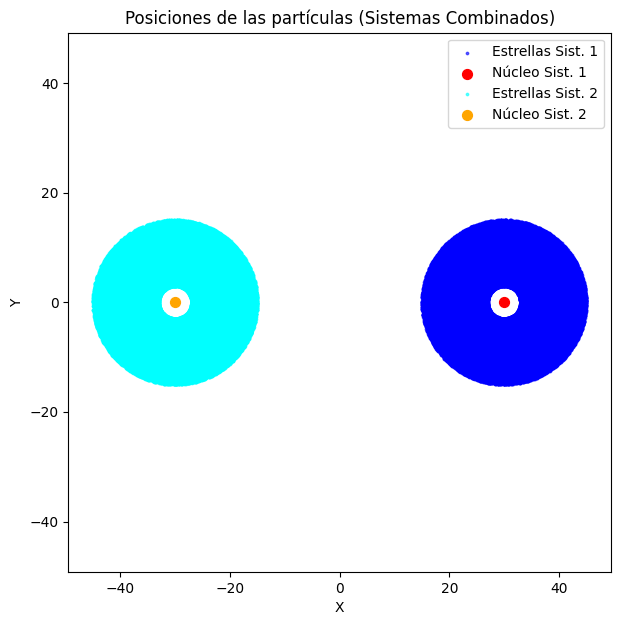

In [ ]:
galaxia1 = Galaxia(num_estrellas=100_000, masa_nucleo=1e3,
                   radio_min=3.0, radio_max=15.0)
galaxia2 = Galaxia(num_estrellas=100_000, masa_nucleo=1e3,
                    radio_min=3.0, radio_max=15.0)

sistema_combinado = Merged_sistem([galaxia1, galaxia2],
                                  velocity_offset=[np.array([-0.0, 2.0, 0.0]), np.array([0.0, -2.0, 0.0])])
sistema_combinado.plot_positions()

In [ ]:
from IPython.display import HTML

anim = sistema_combinado.animate_trajectories(dt=0.05, T=100.0, step_skip=10)
HTML(anim.to_jshtml())



In [ ]:
anim.save('sistemas_combinados.gif', writer='pillow', fps=20)

In [ ]:
sistema_combinado.t_relax

2778.2984506705234

In [ ]:
galaxia1.t_relax

755.0261012680214

## Ejemplo con 3 galaxias en colisión


In [ ]:
galaxia1 = Galaxia(num_estrellas=10_000, masa_nucleo=1e3,
                   radio_min= 4, radio_max=10.0)
galaxia2 = Galaxia(num_estrellas=10_000, masa_nucleo=1e3,
                   radio_min= 4, radio_max=10.0)
galaxia3 = Galaxia(num_estrellas=10_000, masa_nucleo=1e3,
                    radio_min= 4, radio_max=10.0)
sistema_combinado = Merged_sistem([galaxia1, galaxia2, galaxia3],
                                  velocity_offset=[np.array([-0.0, 2.0, 0.0]), np.array([0.0, -2.0, 0.0]), np.array([2.0, 0.0, 0.0])])

sistema_combinado.t_relax


581.1865907421419

In [ ]:
anim = sistema_combinado.animate_trajectories(dt=0.01, T=10.0, step_skip=10)

In [ ]:
HTML(anim.to_jshtml())